# Cluster HFpEF Visualization

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sn

from IPython.display import display

from preproc import get_hfpef_100, get_hfpef_100_nomiss_selected_feats, convert2np

In [2]:
no_clusters = 8
lbl_colname= ['Death', 'CV death', 'HF hospitalization']

## Get Data

In [3]:
data_df = get_hfpef_100()

In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 98 entries, 0 to 99
Data columns (total 45 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 98 non-null     int64  
 1   Sex                 98 non-null     int64  
 2   Cr                  98 non-null     float64
 3   GFR                 98 non-null     float64
 4   CKD stage           98 non-null     int64  
 5   smoke               98 non-null     float64
 6   BMI                 98 non-null     float64
 7   DM                  98 non-null     int64  
 8   Insulin             98 non-null     int64  
 9   AF                  98 non-null     int64  
 10  SBP                 98 non-null     float64
 11  DBP                 98 non-null     float64
 12  MAP                 98 non-null     float64
 13  PP                  98 non-null     int64  
 14  HR                  98 non-null     float64
 15  ACE-i               98 non-null     int64  
 16  ARB       

In [6]:
data_df.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,DM,Insulin,AF,...,e/E',lateral e/E',E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LAVI,LA diameter,LVEF
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,...,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000
mean,71.959184,1.663265,1.785408,50.869592,2.846939,0.132653,21.114286,0.581633,0.316327,0.367347,...,14.155561,12.738469,0.782552,16.743163,2.015612,0.698551,115.998878,27.176531,2.545612,62.105102
std,11.604228,0.475023,1.570997,26.728925,1.096875,0.340943,11.354485,0.495827,0.467433,0.484561,...,7.488935,6.640708,0.691967,8.067268,1.439859,0.422547,53.494470,26.203525,2.147586,7.225176
min,34.000000,1.000000,0.550000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000
25%,65.000000,1.000000,0.892500,27.250000,2.000000,0.000000,18.700000,0.000000,0.000000,0.000000,...,9.812500,8.625000,0.500000,11.800000,0.000000,0.432500,85.075000,0.000000,0.000000,56.000000
50%,74.000000,2.000000,1.170000,52.000000,3.000000,0.000000,23.300000,1.000000,0.000000,0.000000,...,13.615000,12.150000,0.700000,16.300000,2.575000,0.580000,113.850000,28.050000,3.600000,61.250000
75%,79.000000,2.000000,1.982500,68.750000,4.000000,0.000000,28.475000,1.000000,1.000000,1.000000,...,18.825000,16.575000,1.000000,20.850000,3.040000,0.900000,138.905000,44.725000,4.400000,67.300000
max,97.000000,2.000000,10.000000,105.000000,5.000000,1.000000,45.000000,1.000000,1.000000,1.000000,...,33.750000,30.700000,4.100000,42.200000,4.550000,2.300000,356.600000,107.700000,6.000000,80.000000


## 1. All Features

In [7]:
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture

from sklearn.pipeline import make_pipeline

from utils import get_score, score_columns, plot_data

import matplotlib.pyplot as plt
%matplotlib inline
# plt.style.use('seaborn')

In [8]:
X, y, feature_list = convert2np(data_df, lbl_colname)

In [9]:
def get_km_pred(k, X):
    km = KMeans(n_clusters=k, random_state=0)
    return km.fit_predict(X)

def get_sc_pred(k, X):
    sc = SpectralClustering(n_clusters=k, eigen_solver='arpack', affinity="nearest_neighbors", random_state=0)
    return sc.fit_predict(X)

def get_gm_pred(k, X):
    gm = GaussianMixture(n_components=k, random_state=0, init_params='kmeans').fit(X)
    return gm.predict(X)

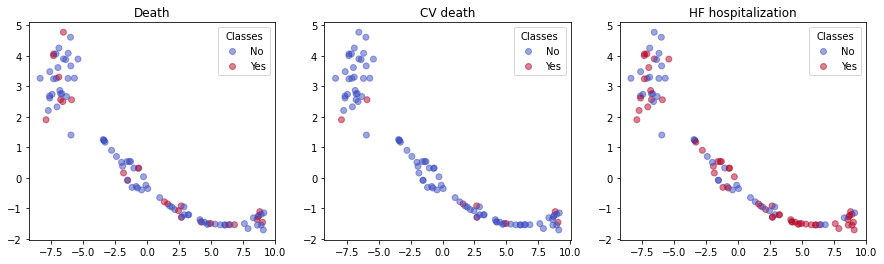

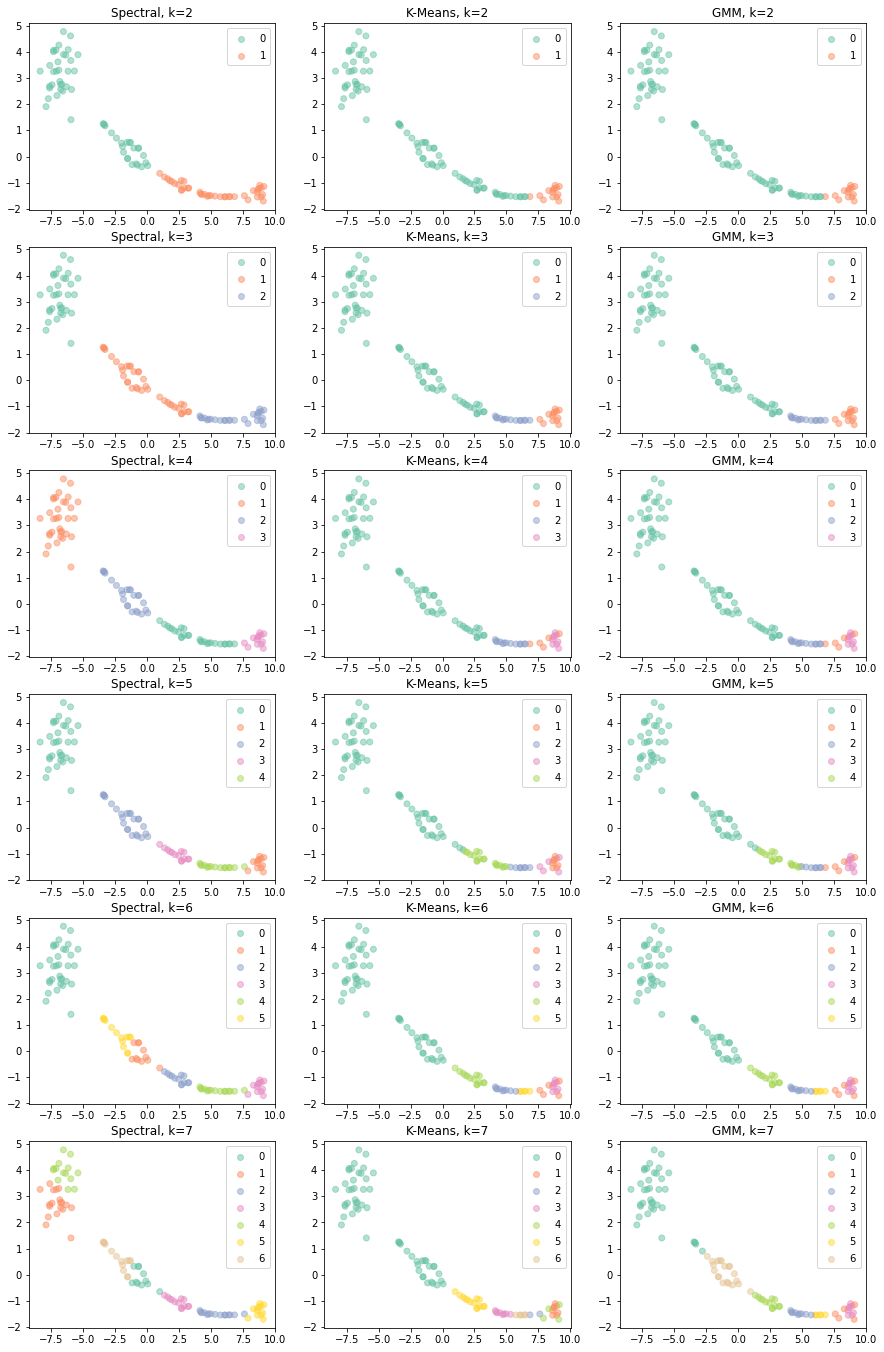

In [10]:
plot_data(X, y, no_clusters, {"Spectral":get_sc_pred, "K-Means":get_km_pred, "GMM":get_gm_pred}, lbl_colname)

## 2. Selected Feature

In [12]:
X, y, feature_list = convert2np(data_df, lbl_colname, selected_feat=True)

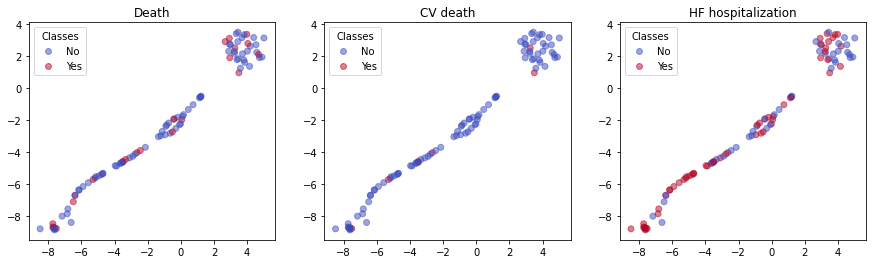

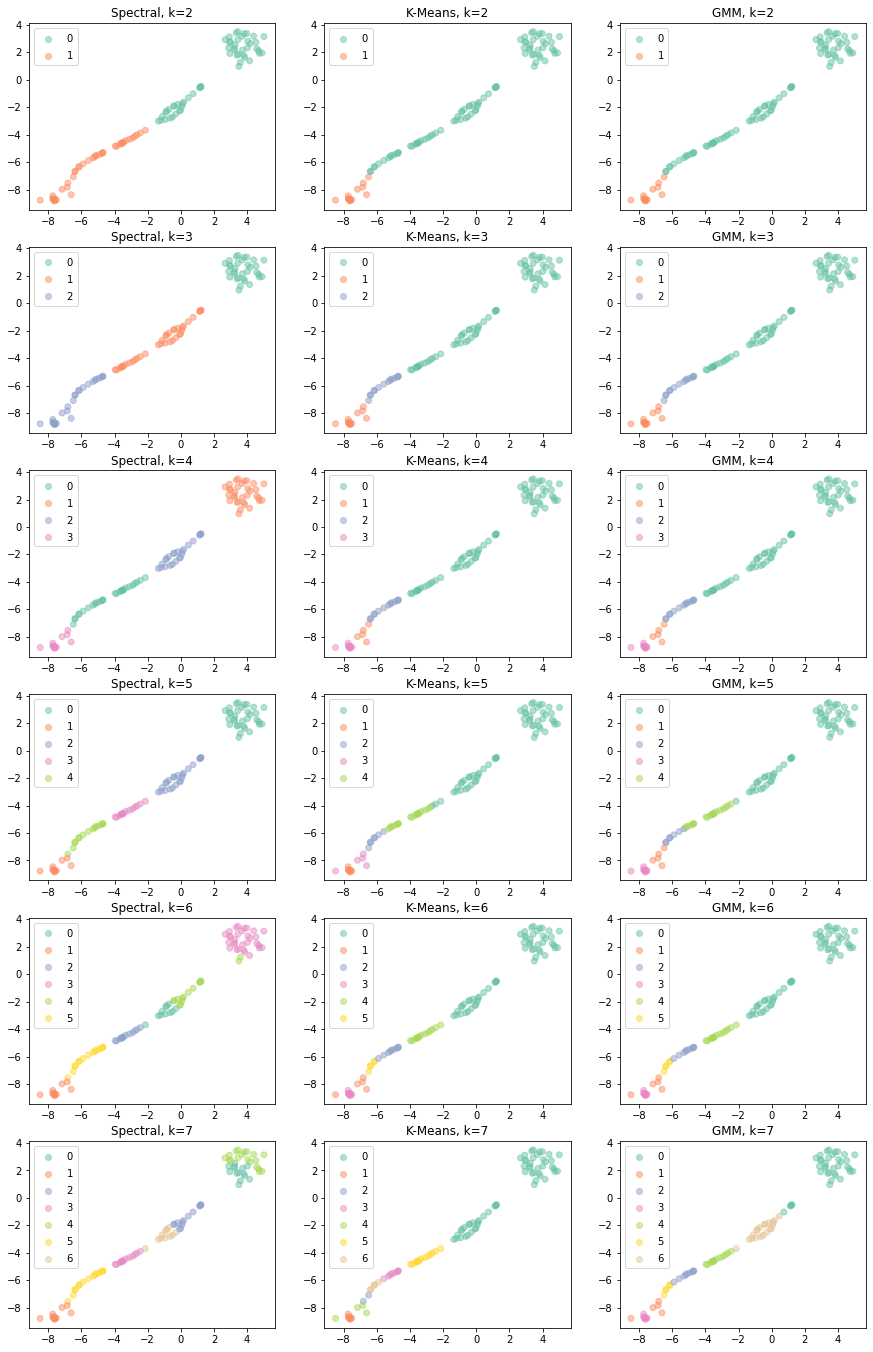

In [13]:
plot_data(X, y, no_clusters, {"Spectral":get_sc_pred, "K-Means":get_km_pred, "GMM":get_gm_pred}, lbl_colname)

## Get Cleaned Data

In [14]:
data_df_clean = get_hfpef_100_nomiss_selected_feats()

In [16]:
data_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 51 entries, 1 to 97
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 51 non-null     int64  
 1   Sex                 51 non-null     int64  
 2   Cr                  51 non-null     float64
 3   GFR                 51 non-null     float64
 4   CKD stage           51 non-null     int64  
 5   AF                  51 non-null     int64  
 6   MAP                 51 non-null     float64
 7   PP                  51 non-null     int64  
 8   NTProBNP            51 non-null     float64
 9   medial a'           51 non-null     float64
 10  medial E'           51 non-null     float64
 11  LAVI                51 non-null     float64
 12  LA diameter         51 non-null     float64
 13  Death               51 non-null     int64  
 14  CV death            51 non-null     int64  
 15  HF hospitalization  51 non-null     int64  
dtypes: float64

In [17]:
data_df_clean.describe()

,Age,Sex,Cr,GFR,CKD stage,AF,MAP,PP,NTProBNP,medial a',medial E',LAVI,LA diameter,Death,CV death,HF hospitalization
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,72.235294,1.627451,2.000980,50.958431,2.862745,0.215686,93.490196,71.764706,9129.700784,7.794118,5.083333,29.774510,2.411765,0.176471,0.078431,0.627451
std,11.885433,0.488294,1.922055,29.636126,1.249314,0.415390,10.019393,19.344858,11348.285521,2.668111,1.659339,24.976924,2.109848,0.385013,0.271524,0.488294
min,34.000000,1.000000,0.630000,2.000000,1.000000,0.000000,70.000000,25.000000,41.740000,2.020000,2.760000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,67.000000,1.000000,0.875000,22.000000,2.000000,0.000000,87.500000,60.000000,1174.500000,6.220000,3.685000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,75.000000,2.000000,1.130000,58.000000,3.000000,0.000000,94.333333,69.000000,3493.000000,7.770000,4.760000,30.900000,3.500000,0.000000,0.000000,1.000000
75%,78.500000,2.000000,2.225000,73.000000,4.000000,0.000000,100.000000,81.500000,12887.000000,9.870000,6.290000,42.100000,4.100000,0.000000,0.000000,1.000000
max,92.000000,2.000000,10.000000,105.000000,5.000000,1.000000,117.000000,124.000000,35001.000000,12.800000,9.160000,107.700000,6.000000,1.000000,1.000000,1.000000


## 3. Cleaned Data

In [18]:
X, y, feature_list = convert2np(data_df_clean, lbl_colname, selected_feat=True)

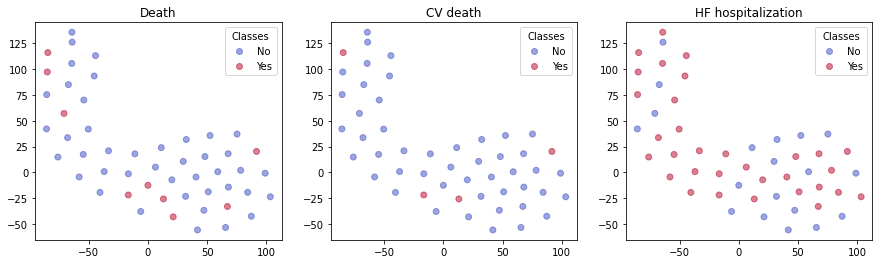

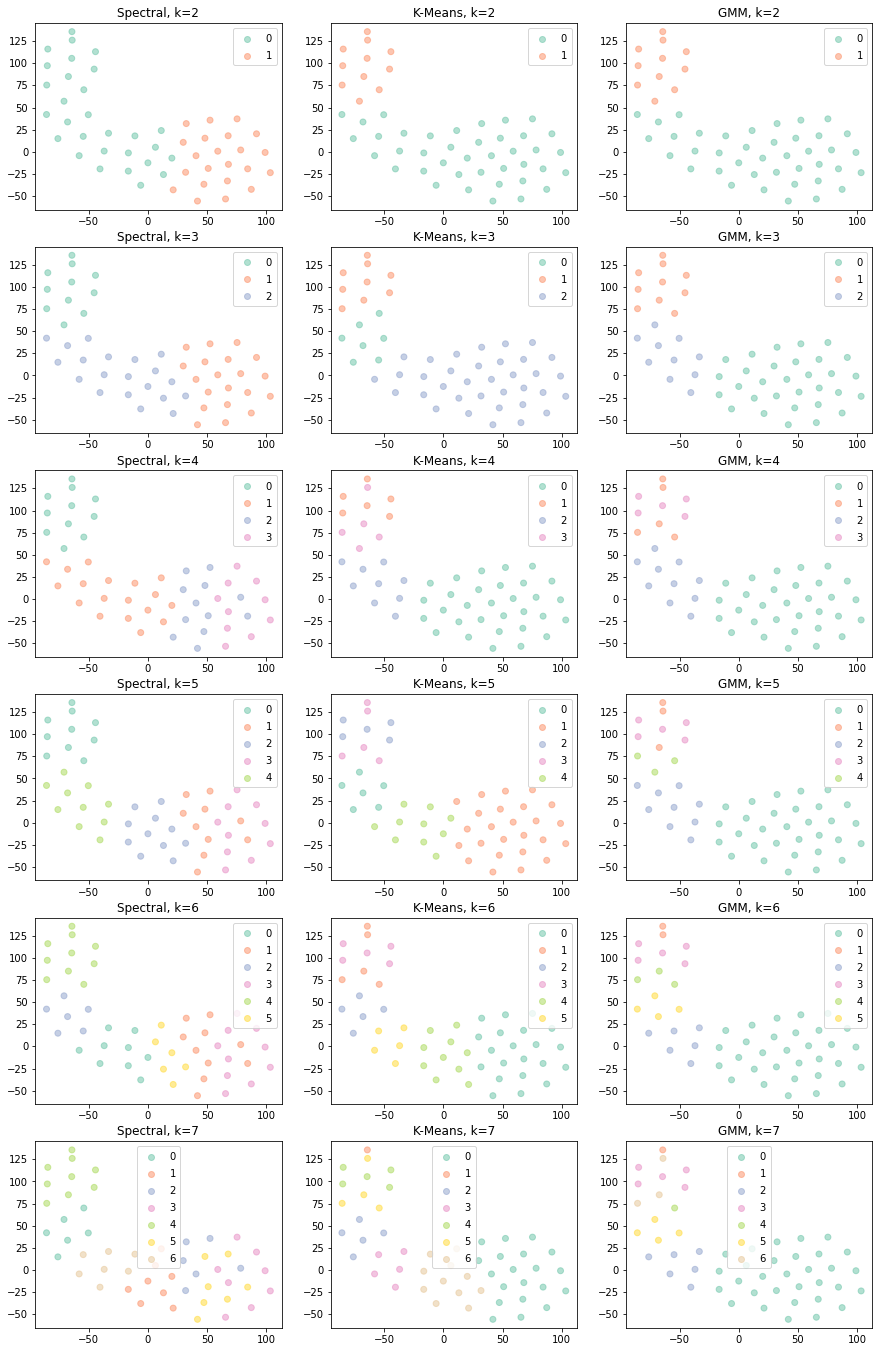

In [19]:
plot_data(X, y, no_clusters, {"Spectral":get_sc_pred, "K-Means":get_km_pred, "GMM":get_gm_pred}, lbl_colname)